In [1]:
!pip install malariagen-data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 47.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.8/215.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 76.0 MB/s eta 0:00:00
  

# MalariaGen - Exploratory Data Analysis

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import malariagen_data
import seaborn as sns

## Anopeheles Gambiae

### Loading Data


In [21]:
ag3 = malariagen_data.Ag3()
df_samples_ag3 = ag3.sample_metadata(sample_sets="3.0")
df_samples_ag3

,sample_id,partner_sample_id,contributor,country,location,year,month,latitude,longitude,sex_call,...,admin1_name,admin1_iso,admin2_name,taxon,cohort_admin1_year,cohort_admin1_month,cohort_admin1_quarter,cohort_admin2_year,cohort_admin2_month,cohort_admin2_quarter
0,AR0047-C,LUA047,Joao Pinto,Angola,Luanda-A,2009,4,-8.884,13.302,F,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
1,AR0049-C,LUA049,Joao Pinto,Angola,Luanda-A,2009,4,-8.884,13.302,F,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
2,AR0051-C,LUA051,Joao Pinto,Angola,Luanda-A,2009,4,-8.884,13.302,F,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
3,AR0061-C,LUA061,Joao Pinto,Angola,Luanda-A,2009,4,-8.884,13.302,F,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
4,AR0078-C,LUA078,Joao Pinto,Angola,Luanda-A,2009,4,-8.884,13.302,F,...,Luanda,AO-LUA,Luanda,coluzzii,AO-LUA_colu_2009,AO-LUA_colu_2009_04,AO-LUA_colu_2009_Q2,AO-LUA_Luanda_colu_2009,AO-LUA_Luanda_colu_2009_04,AO-LUA_Luanda_colu_2009_Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3076,AD0494-C,80-2-o-16,Martin Donnelly,Lab Cross,LSTM,-1,-1,53.409,-2.969,F,...,NaN,NaN,NaN,unassigned,NaN,NaN,NaN,NaN,NaN,NaN
3077,AD0495-C,80-2-o-17,Martin Donnelly,Lab Cross,LSTM,-1,-1,53.409,-2.969,M,...,NaN,NaN,NaN,unassigned,NaN,NaN,NaN,NaN,NaN,NaN
3078,AD0496-C,80-2-o-18,Martin Donnelly,Lab Cross,LSTM,-1,-1,53.409,-2.969,M,...,NaN,NaN,NaN,unassigned,NaN,NaN,NaN,NaN,NaN,NaN
3079,AD0497-C,80-2-o-19,Martin Donnelly,Lab Cross,LSTM,-1,-1,53.409,-2.969,F,...,NaN,NaN,NaN,unassigned,NaN,NaN,NaN,NaN,NaN,NaN


### Frequency of each Taxon

In [15]:
df_samples_ag3.groupby("taxon").size()

,0
taxon,
arabiensis,368
bissau,170
coluzzii,705
gambiae,1473
pwani,65
unassigned,300


### Population Sampling

In [22]:
pivot_country_taxon_ag3 = (
    df_samples_ag3
    .pivot_table(
        index="country",
        columns="taxon",
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_country_taxon_ag3

taxon,arabiensis,bissau,coluzzii,gambiae,pwani,unassigned
country,,,,,,
Angola,0,0,81,0,0,0
Burkina Faso,3,0,135,158,0,0
Cameroon,2,0,26,416,0,0
Central African Republic,0,0,18,55,0,0
Cote d'Ivoire,0,0,80,0,0,0
Democratic Republic of the Congo,0,0,0,76,0,0
Equatorial Guinea,0,0,0,10,0,0
Gabon,0,0,0,69,0,0
"Gambia, The",0,77,200,2,0,0


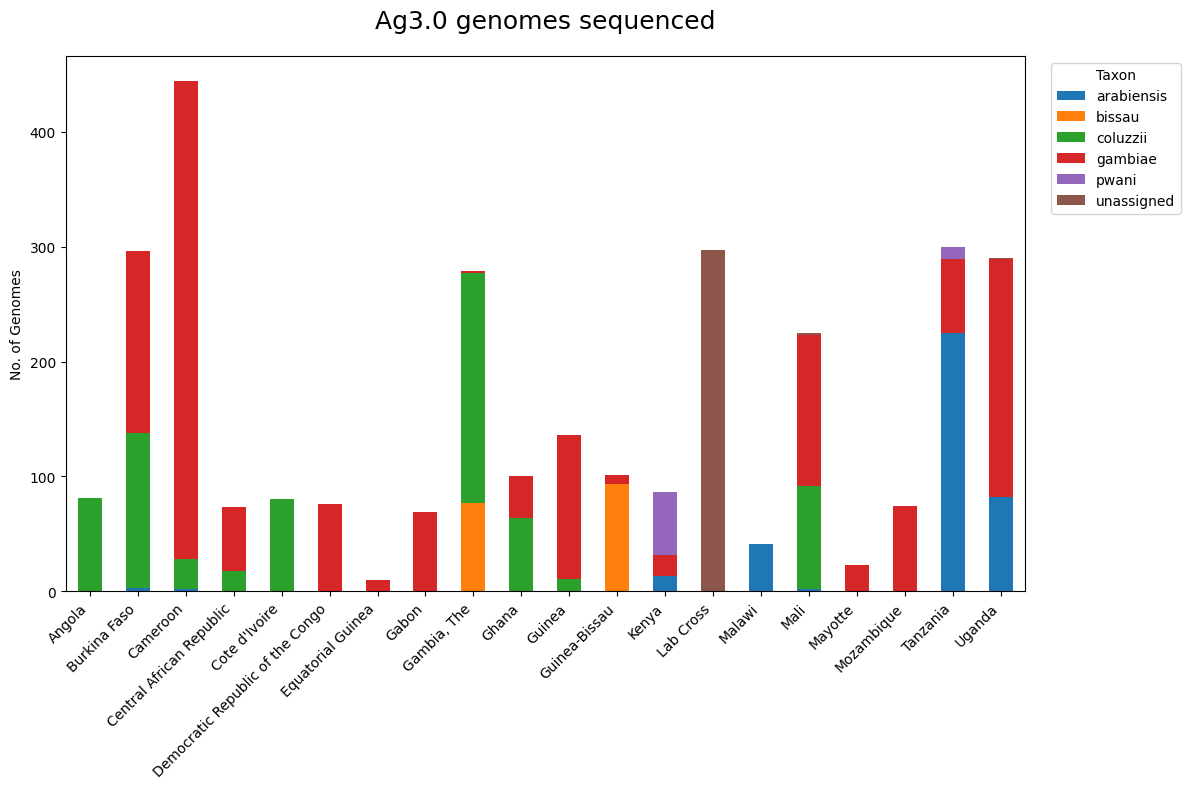

In [24]:
pivot_country_taxon_ag3.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 8)
)

plt.title("Ag3.0 genomes sequenced", fontsize=18, pad=20)
plt.ylabel("No. of Genomes")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Taxon", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Population Structure

#### PCA

In [4]:
region = "3L:15,000,000-41,000,000"
n_snps = 100_000

In [5]:
pca_bf_df, evr_bf = ag3.pca(
    region=region,
    n_snps=n_snps,
    sample_sets="AG1000G-BF-B",
);

pca_bf_df

Compute SNP allele counts:   0%|          | 0/1033 [00:00<?, ?it/s]

Compute biallelic diplotypes:   0%|          | 0/1377 [00:00<?, ?it/s]

,sample_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,admin1_iso,admin2_name,taxon,cohort_admin1_year,cohort_admin1_month,cohort_admin1_quarter,cohort_admin2_year,cohort_admin2_month,cohort_admin2_quarter,pca_fit
0,AB0326-C,-45.147316,49.256832,-1.998586,-5.135554,8.505875,5.893218,-1.747894,1.711392,3.469684,...,BF-09,Houet,coluzzii,BF-09_colu_2014,BF-09_colu_2014_07,BF-09_colu_2014_Q3,BF-09_Houet_colu_2014,BF-09_Houet_colu_2014_07,BF-09_Houet_colu_2014_Q3,True
1,AB0327-C,-46.236706,49.814014,-0.505994,-6.519270,4.586233,0.889032,-0.178112,-10.316228,-9.113003,...,BF-09,Houet,coluzzii,BF-09_colu_2014,BF-09_colu_2014_07,BF-09_colu_2014_Q3,BF-09_Houet_colu_2014,BF-09_Houet_colu_2014_07,BF-09_Houet_colu_2014_Q3,True
2,AB0328-C,-45.168800,50.684898,5.050784,6.283825,1.774286,-0.620942,1.740285,-24.983717,41.198116,...,BF-09,Houet,coluzzii,BF-09_colu_2014,BF-09_colu_2014_07,BF-09_colu_2014_Q3,BF-09_Houet_colu_2014,BF-09_Houet_colu_2014_07,BF-09_Houet_colu_2014_Q3,True
3,AB0329-C,-40.808823,49.916782,-0.335172,2.825975,5.021981,-2.287129,-1.162532,13.938565,-13.941393,...,BF-09,Houet,coluzzii,BF-09_colu_2014,BF-09_colu_2014_07,BF-09_colu_2014_Q3,BF-09_Houet_colu_2014,BF-09_Houet_colu_2014_07,BF-09_Houet_colu_2014_Q3,True
4,AB0330-C,-45.118183,51.813442,3.615408,5.880900,0.891817,8.472662,-2.446120,10.844000,0.425988,...,BF-09,Houet,coluzzii,BF-09_colu_2014,BF-09_colu_2014_07,BF-09_colu_2014_Q3,BF-09_Houet_colu_2014,BF-09_Houet_colu_2014_07,BF-09_Houet_colu_2014_Q3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,AB0533-C,28.706097,-63.657158,-17.343046,-16.055662,3.447080,-38.785667,-2.374830,18.463909,33.561306,...,BF-09,Houet,gambiae,BF-09_gamb_2014,BF-09_gamb_2014_07,BF-09_gamb_2014_Q3,BF-09_Houet_gamb_2014,BF-09_Houet_gamb_2014_07,BF-09_Houet_gamb_2014_Q3,True
98,AB0536-C,27.803598,-72.293945,-15.643853,-17.562124,-16.875465,-31.170620,-15.381256,-33.210396,-83.346222,...,BF-09,Houet,gambiae,BF-09_gamb_2014,BF-09_gamb_2014_07,BF-09_gamb_2014_Q3,BF-09_Houet_gamb_2014,BF-09_Houet_gamb_2014_07,BF-09_Houet_gamb_2014_Q3,True
99,AB0537-C,27.678404,-67.297379,-14.966357,-13.990895,-17.428822,-35.409706,-0.580396,-5.069886,13.734659,...,BF-09,Houet,gambiae,BF-09_gamb_2014,BF-09_gamb_2014_07,BF-09_gamb_2014_Q3,BF-09_Houet_gamb_2014,BF-09_Houet_gamb_2014_07,BF-09_Houet_gamb_2014_Q3,True
100,AB0538-C,28.341574,-69.729027,-16.664042,-15.502448,-5.486606,-19.052750,-5.590906,40.449852,58.663013,...,BF-09,Houet,gambiae,BF-09_gamb_2014,BF-09_gamb_2014_07,BF-09_gamb_2014_Q3,BF-09_Houet_gamb_2014,BF-09_Houet_gamb_2014_07,BF-09_Houet_gamb_2014_Q3,True


In [6]:
evr_bf

array([0.02730524, 0.02220054, 0.01423876, 0.01293669, 0.01234468,
       0.01193129, 0.01170423, 0.01034488, 0.01026331, 0.0102485 ,
       0.010171  , 0.01016118, 0.01012879, 0.01011401, 0.01010154,
       0.01005797, 0.01003724, 0.01002417, 0.00999242, 0.0099812 ],
      dtype=float32)

#### Defining tsne function

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE


def tsne(
    df,
    pc_start=1,
    pc_end=20,
    perplexity=10,
    standardize=True,
    label_column="taxon",
    random_state=42,
    plot=True
):
    """
    Perform t-SNE on PCA columns in a dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing PCA columns (e.g., PC1 ... PC20).
    pc_start : int
        First PC index (default=1).
    pc_end : int
        Last PC index (default=20).
    perplexity : int
        t-SNE perplexity parameter.
    standardize : bool
        Whether to standardize PCA features before t-SNE.
    label_column : str
        Column used for coloring plot.
    random_state : int
        Seed for reproducibility.
    plot : bool
        Whether to generate scatter plot.

    Returns
    -------
    df : pandas.DataFrame
        DataFrame with tsne_1 and tsne_2 columns added.
    """

    # --- Select PCA columns ---
    pc_columns = [f"PC{i}" for i in range(pc_start, pc_end + 1)]
    X = df[pc_columns].values

    # --- Standardize if requested ---
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # --- Run t-SNE ---
    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )

    X_tsne = tsne_model.fit_transform(X)

    # --- Add results back ---
    df = df.copy()
    df["tsne_1"] = X_tsne[:, 0]
    df["tsne_2"] = X_tsne[:, 1]

    # --- Plot ---
    if plot:
        plt.figure()
        if label_column in df.columns:
            for label in df[label_column].unique():
                subset = df[df[label_column] == label]
                plt.scatter(subset["tsne_1"], subset["tsne_2"], label=label)
            plt.legend()
        else:
            plt.scatter(df["tsne_1"], df["tsne_2"])

        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.title("t-SNE projection of PCA features")
        plt.show()

    return df

#### Performing tsne

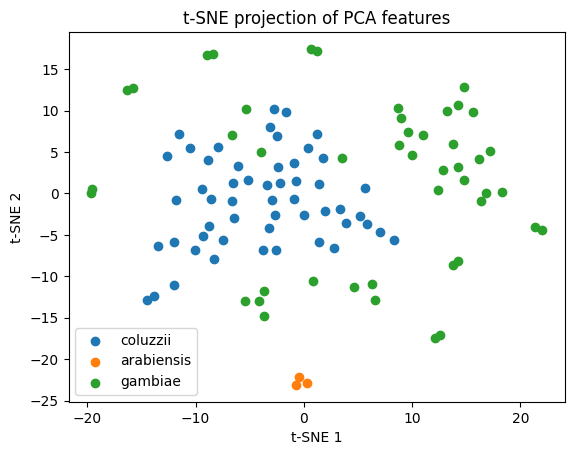

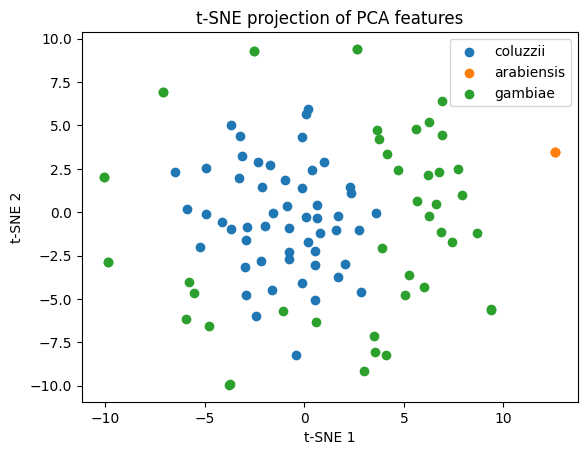

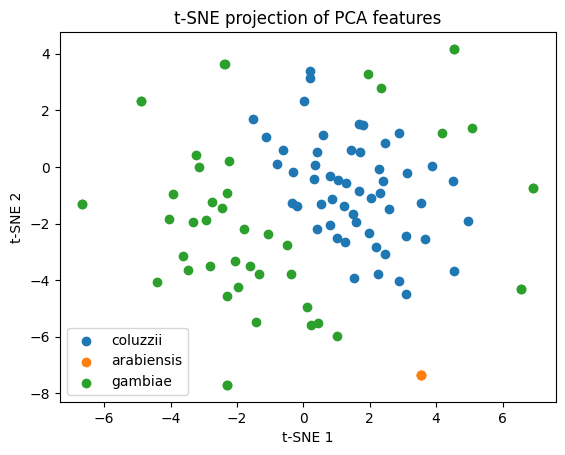

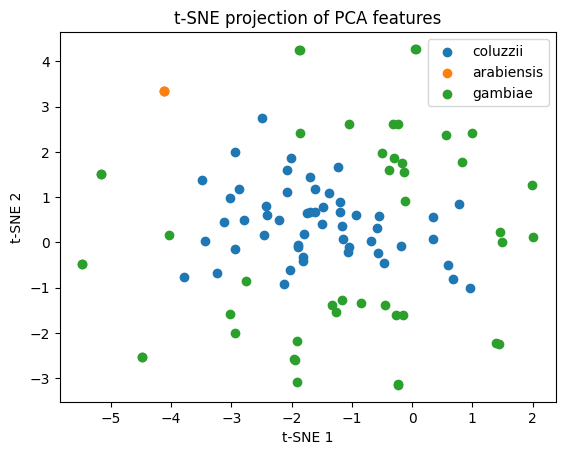

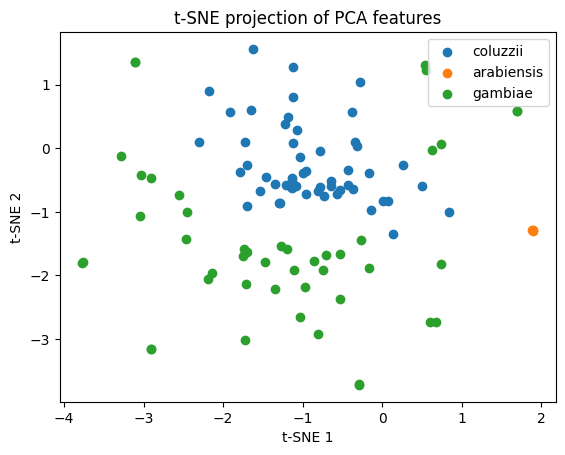

In [17]:
perp = [10, 20, 30, 40, 50]
for i in perp:
  tsne_bf_df = tsne(pca_bf_df, perplexity=i)

Compute SNP allele counts:   0%|          | 0/3957 [00:00<?, ?it/s]

Compute biallelic diplotypes:   0%|          | 0/4817 [00:00<?, ?it/s]

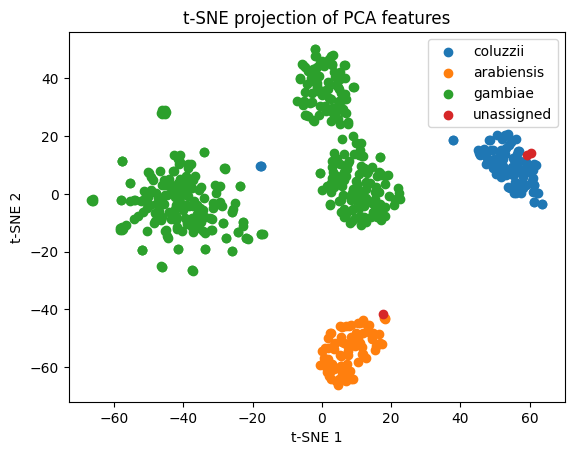

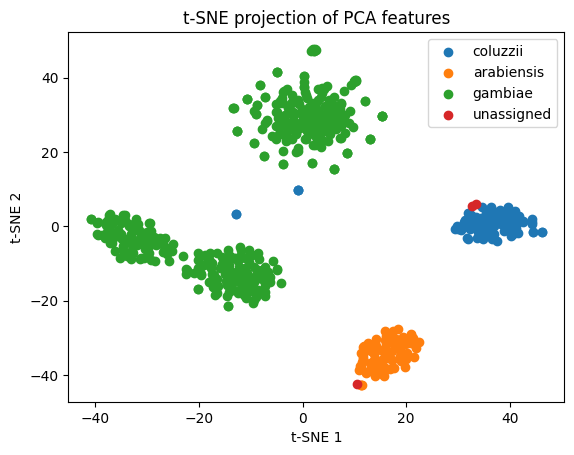

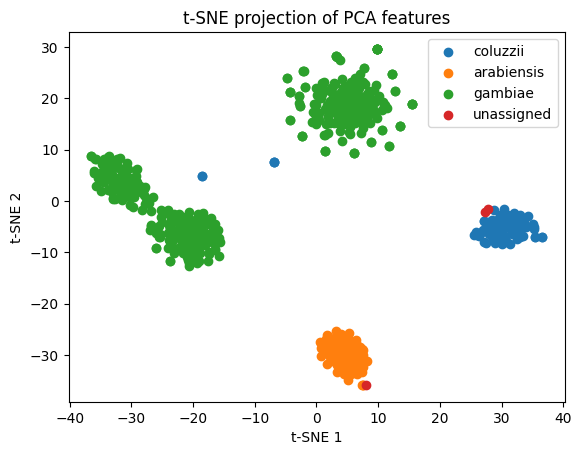

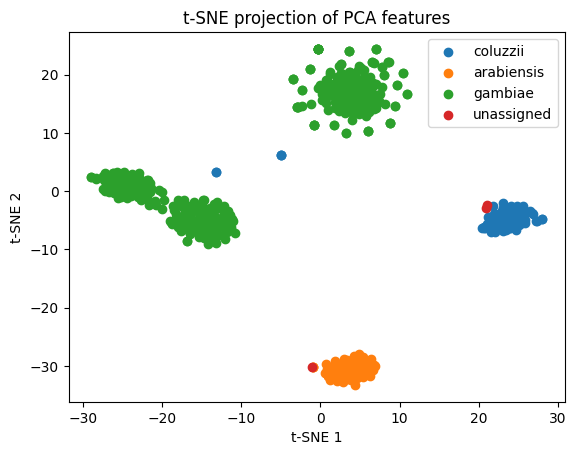

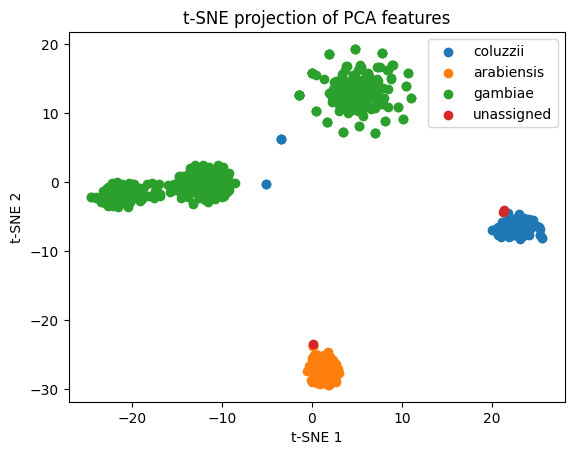

In [22]:
pca_ag3, evr_ag3 = ag3.pca(
    region=region,
    n_snps=n_snps,
    sample_sets=["AG1000G-GN-B", "AG1000G-BF-B", "AG1000G-UG"],
);

perp = [10, 20, 30, 40, 50]
for i in perp:
  tsne_bf_df = tsne(pca_ag3, perplexity=i)

## Anopeheles Funestus

### Loading Data


In [16]:
af1 = malariagen_data.Af1()
df_samples_af1 = af1.sample_metadata(sample_sets="1.0")


### Frequency of each Taxon

In [17]:
df_samples_af1.groupby("taxon").size()

,0
taxon,
funestus,656


In [28]:
pivot_country_taxon_af1 = (
    df_samples_af1
    .pivot_table(
        index="country",
        columns="taxon",
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_country_taxon_af1

taxon,funestus
country,
Benin,37
Cameroon,45
Central African Republic,10
Democratic Republic of the Congo,77
Gabon,40
Ghana,67
Kenya,81
Malawi,18
Mozambique,138


### Population Sampling

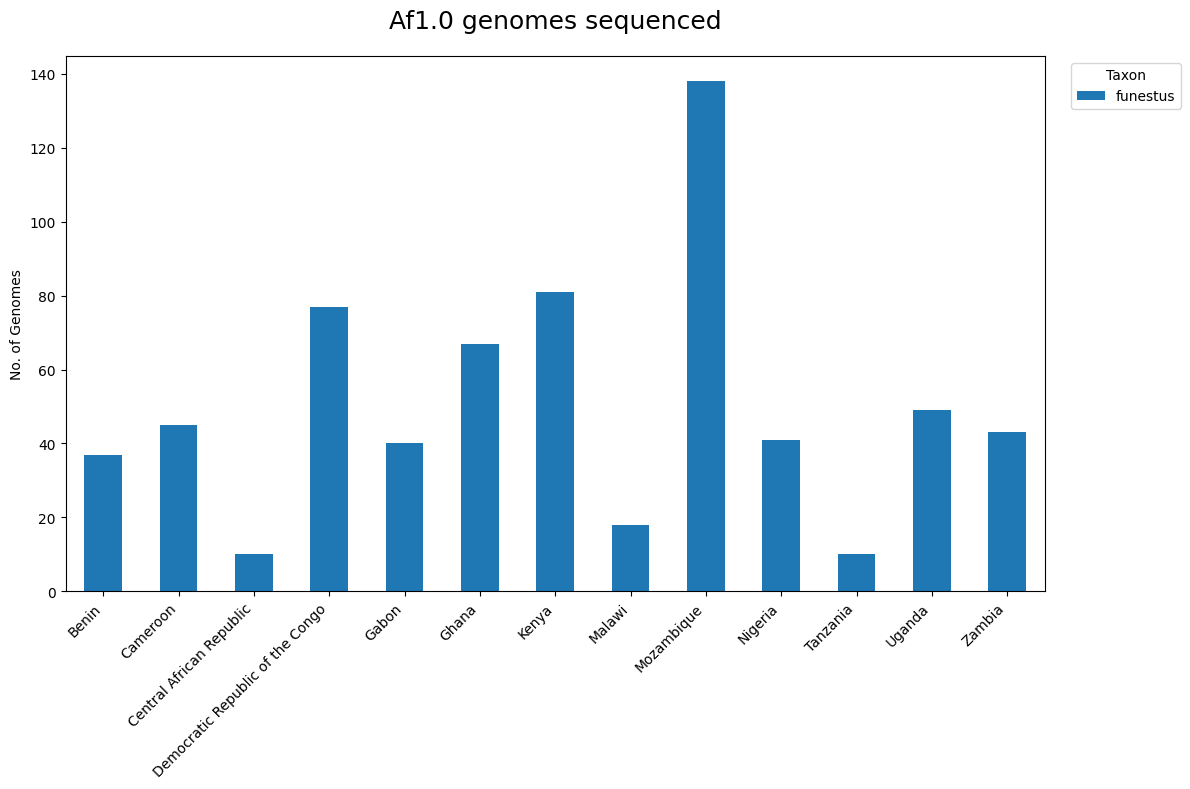

In [29]:
pivot_country_taxon_af1.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 8)
)

plt.title("Af1.0 genomes sequenced", fontsize=18, pad=20)
plt.ylabel("No. of Genomes")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Taxon", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Anopeheles Minimus

### Loading Data


In [18]:
amin1 = malariagen_data.Amin1()
df_samples_amin1 = amin1.sample_metadata(sample_sets="1.0")


### Frequency of each Taxon

In [19]:
df_samples_amin1.groupby("taxon").size()

,0
taxon,
minimus,302


In [32]:
pivot_country_taxon_amin1 = (
    df_samples_amin1
    .pivot_table(
        index="country",
        columns="taxon",
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_country_taxon_amin1

taxon,minimus
country,
Cambodia,302


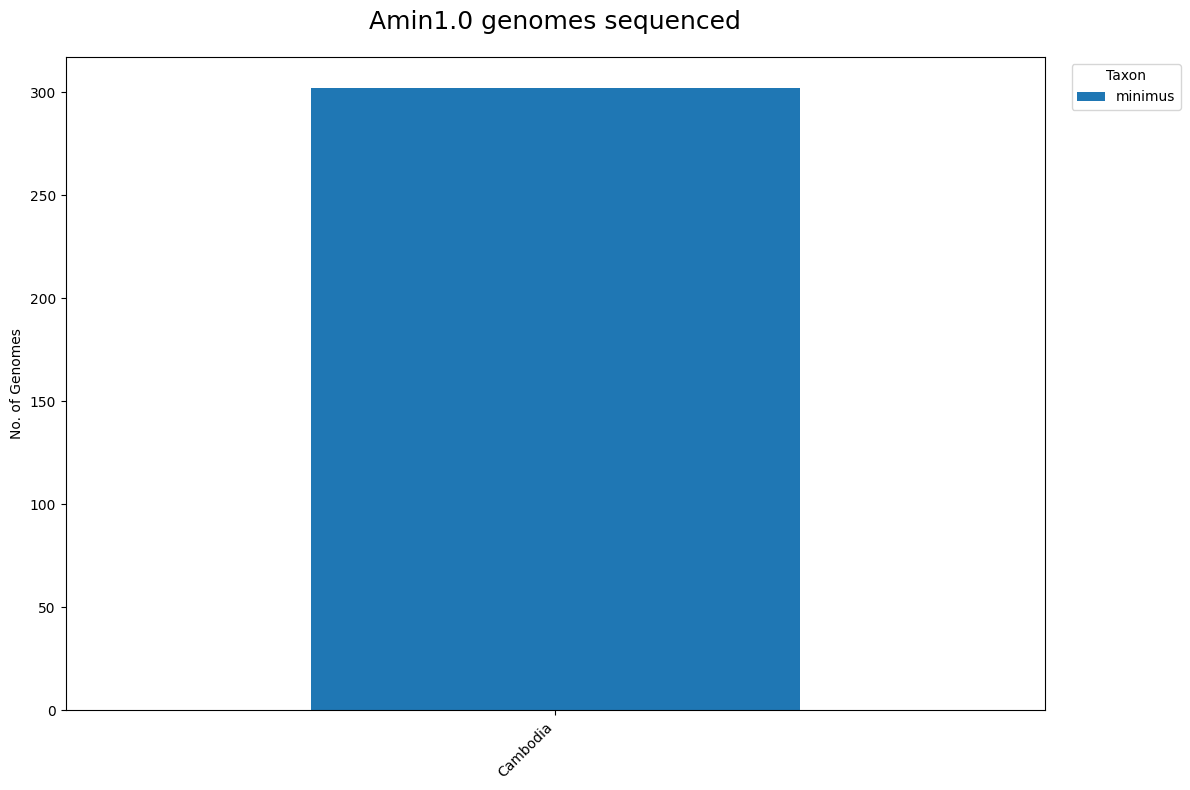

In [31]:
pivot_country_taxon_amin1.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 8)
)

plt.title("Amin1.0 genomes sequenced", fontsize=18, pad=20)
plt.ylabel("No. of Genomes")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Taxon", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()